In [2]:
import os

# Core LSD imports
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks
from sclsd.analysis import cross_boundary_correctness


from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc

import numpy as np


print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

# Configure computational device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
set_all_seeds(SEED)

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.4.1+cu121
Scanpy version: 1.11.5
Using device: cuda:1


/projects/apour/.cache/tmp/ipykernel_1092710/165984558.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [3]:
adata = sc.read("../../Zenodo/Human_germline/preprocessed_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 10971 × 1999
    obs: 'n_genes', 'sample', 'location', 'trimester', 'celltype', 'sex', 'tissue', 'development_stage', 'clusters', 'prior_pseudotime', 'PCW', 'librarysize'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'means', 'dispersions', 'dispersions_norm'
    uns: 'TP_colors', 'ccgs', 'celltype_colors', 'citation', 'clusters_colors', 'default_embedding', 'donor_id_colors', 'hvg', 'lineage_colors', 'neighbors', 'organism', 'organism_ontology_term_id', 'pca', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'connectivities', 'distances', 'phylogeny_matrix'

In [3]:
phylogeny = {
    "primordial germ cell":      ["germ cell"],
    "germ cell":            ["male germ cell", "oogonial cell"],                 
    "oogonial cell":          ["oocyte"],           
    "male germ cell":              [],
    "oocyte":               [],                                      
}


In [4]:
def prepare_branch_balanced_walks(
    lsd,
    n_walks,
    cluster_key,
    branch_targets,
    pool_size=None,
    pool_multiplier=8,
    random_state=SEED,
):
    if pool_size is None:
        pool_size = pool_multiplier * n_walks
    if pool_size < n_walks:
        raise ValueError("pool_size must be at least n_walks")

    branch_names = list(branch_targets)
    if len(branch_names) != 2:
        raise ValueError("This helper expects exactly two branch targets")

    terminal_to_branch = {}
    for branch_name, terminal_clusters in branch_targets.items():
        for cluster_name in terminal_clusters:
            terminal_to_branch[cluster_name] = branch_name

    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)

    lsd.P = lsd.P.to(lsd.device)
    candidate_walks = lsd._random_walks(pool_size).cpu()
    lsd.P = lsd.P.cpu()

    endpoint_clusters = (
        lsd.adata.obs[cluster_key]
        .iloc[candidate_walks[:, -1].numpy()]
        .astype(str)
        .tolist()
    )

    branch_to_indices = {branch_name: [] for branch_name in branch_names}
    for walk_idx, cluster_name in enumerate(endpoint_clusters):
        branch_name = terminal_to_branch.get(cluster_name)
        if branch_name is not None:
            branch_to_indices[branch_name].append(walk_idx)

    required_per_branch = {
        branch_name: n_walks // len(branch_names) for branch_name in branch_names
    }
    for branch_name in branch_names[: n_walks % len(branch_names)]:
        required_per_branch[branch_name] += 1

    available_per_branch = {
        branch_name: len(indices) for branch_name, indices in branch_to_indices.items()
    }
    missing = {
        branch_name: required_per_branch[branch_name] - available_per_branch[branch_name]
        for branch_name in branch_names
        if available_per_branch[branch_name] < required_per_branch[branch_name]
    }
    if missing:
        raise ValueError(
            f"Not enough walks in one or more branches: {missing}. "
            f"Available counts: {available_per_branch}. Increase pool_size or pool_multiplier."
        )

    selected_candidate_indices = []
    for branch_name in branch_names:
        branch_indices = branch_to_indices[branch_name]
        branch_order = torch.randperm(len(branch_indices))
        n_branch = required_per_branch[branch_name]
        selected_candidate_indices.extend(
            branch_indices[i] for i in branch_order[:n_branch].tolist()
        )

    selected_candidate_indices = torch.tensor(selected_candidate_indices, dtype=torch.long)
    selected_order = torch.randperm(len(selected_candidate_indices))
    selected_candidate_indices = selected_candidate_indices[selected_order]

    lsd.walks = candidate_walks[selected_candidate_indices]

    selected_endpoint_clusters = [
        endpoint_clusters[i] for i in selected_candidate_indices.tolist()
    ]
    selected_branch_counts = {
        branch_name: sum(
            terminal_to_branch[cluster_name] == branch_name
            for cluster_name in selected_endpoint_clusters
        )
        for branch_name in branch_names
    }

    print(f"Candidate endpoint counts: {available_per_branch}")
    print(f"Selected endpoint counts: {selected_branch_counts}")
    return lsd.walks


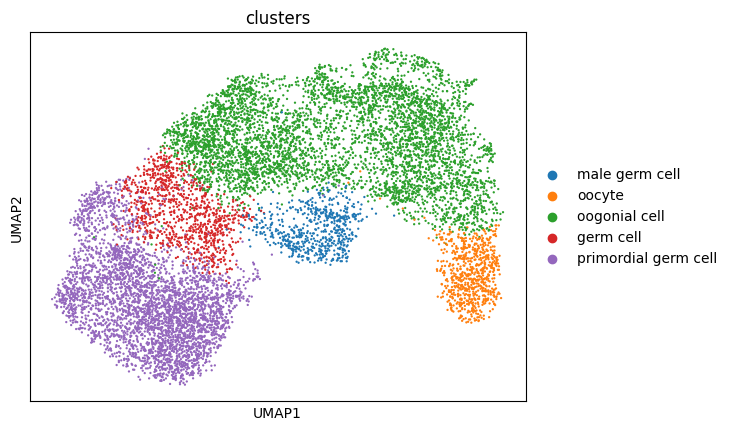

In [5]:
colors = ["clusters"]
sc.pl.umap(adata, color = colors)

[LSD] Removing 22 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.
Candidate endpoint counts: {'male_branch': 5258, 'female_branch': 9757}
Selected endpoint counts: {'male_branch': 2048, 'female_branch': 2048}


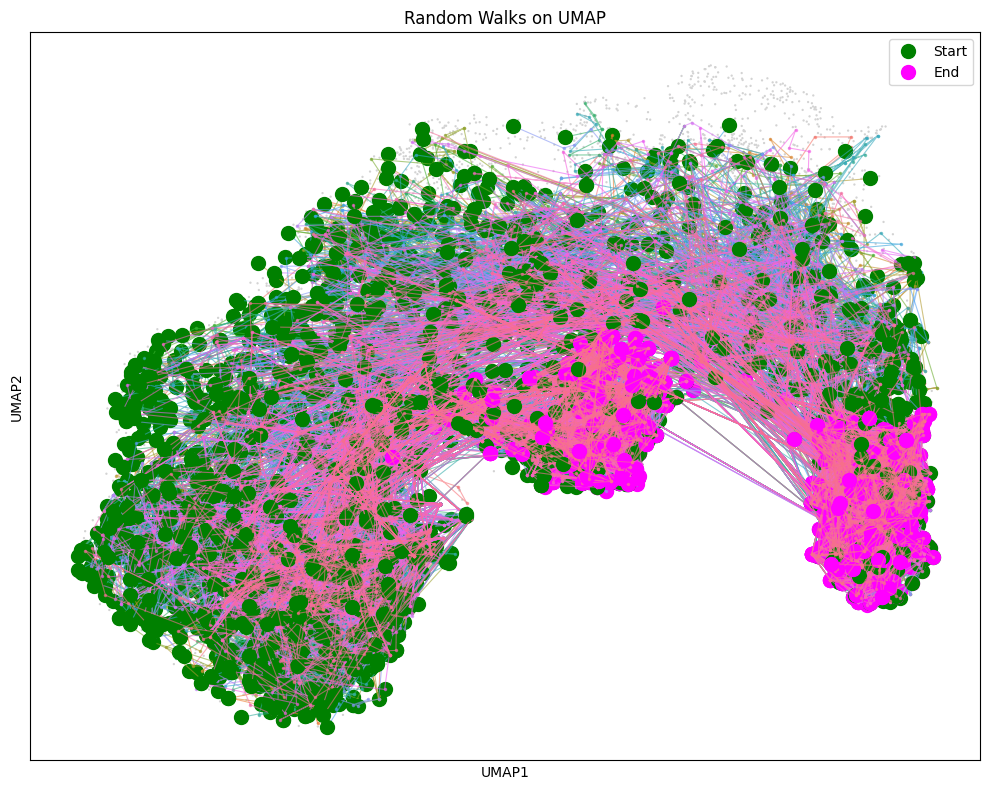

In [6]:
# Initialize the LSD model
cfg = LSDConfig()
cfg.walks.random_state = SEED
cfg.walks.num_walks = 4096
cfg.walks.path_len = 16
cfg.walks.batch_size = 512

sc.pp.pca(adata)
sc.pp.neighbors(adata, use_rep= "X_pca")

lsd = LSD(
    adata,
    cfg,            
    device=device,                   
)


# Set phylogenetic relationships
lsd.set_phylogeny(phylogeny, cluster_key="clusters")
# Set prior pseudotime key
lsd.set_prior_transition(prior_time_key="prior_pseudotime")
# Prepare walks on the cell connectivity graph with balanced terminal branches
branch_targets = {
    "male_branch": ["male germ cell"],
    "female_branch": ["oocyte"],
}
prepare_branch_balanced_walks(
    lsd,
    n_walks=cfg.walks.num_walks,
    cluster_key="clusters",
    branch_targets=branch_targets,
    pool_size=8 * cfg.walks.num_walks,
    random_state=SEED,
)
# Visualize a subset of random walks
plot_random_walks(lsd.adata, lsd.walks, "X_umap")

Training Epochs:   0%|          | 0/120 [00:02<?, ?it/s, -ELBO=3.9350, Potential Metric=0.0001, Entropy Metric=0.0104]

Training Epochs: 100%|██████████| 120/120 [05:45<00:00,  2.88s/it, -ELBO=1.9826, Potential Metric=0.1699, Entropy Metric=0.0603]


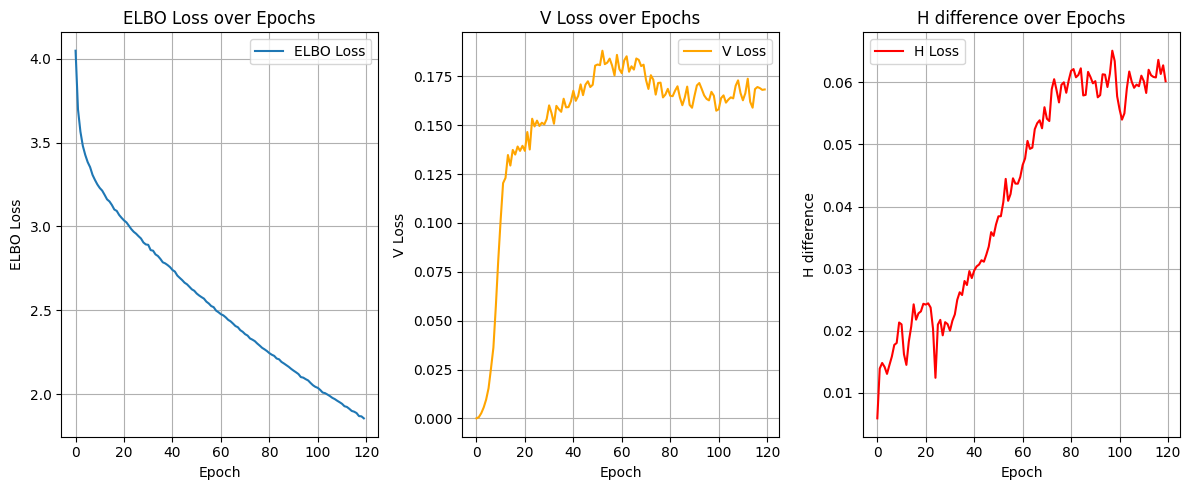

In [ ]:
# Define model directory based on hyperparameters
model_dir = "./model"

# Clear parameter store for fresh training
clear_pyro_state()
# Create save directory
os.makedirs(model_dir, exist_ok=True)
num_epochs = 120     # Total training epochs
# Train the model
lsd.train(
    num_epochs=num_epochs,
    save_dir=model_dir,
    random_state=SEED
)

In [8]:
#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 5, cluster_key = "clusters")

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


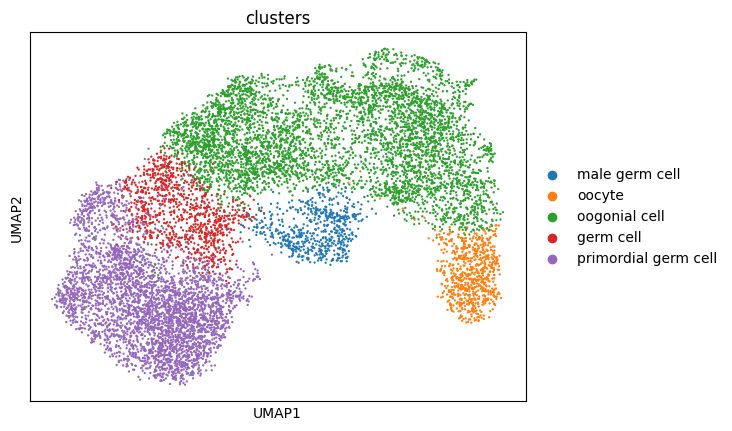

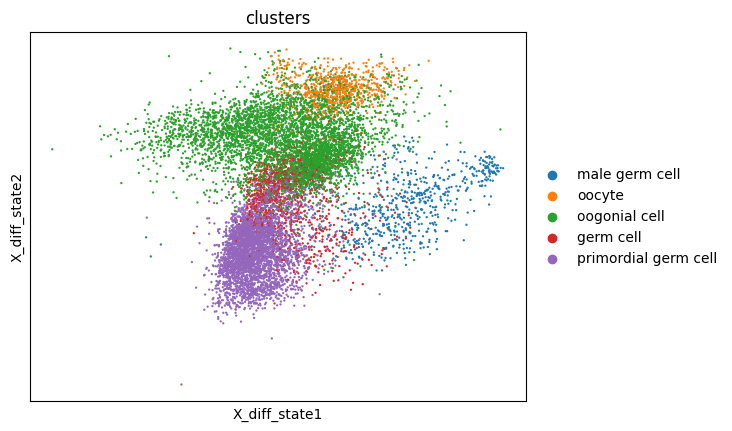

In [9]:
sc.pl.umap(dyn_adata, color = "clusters")
sc.pl.embedding(dyn_adata, color = "clusters", basis = "X_diff_state")

plotting LSD outputs on UMAP projection


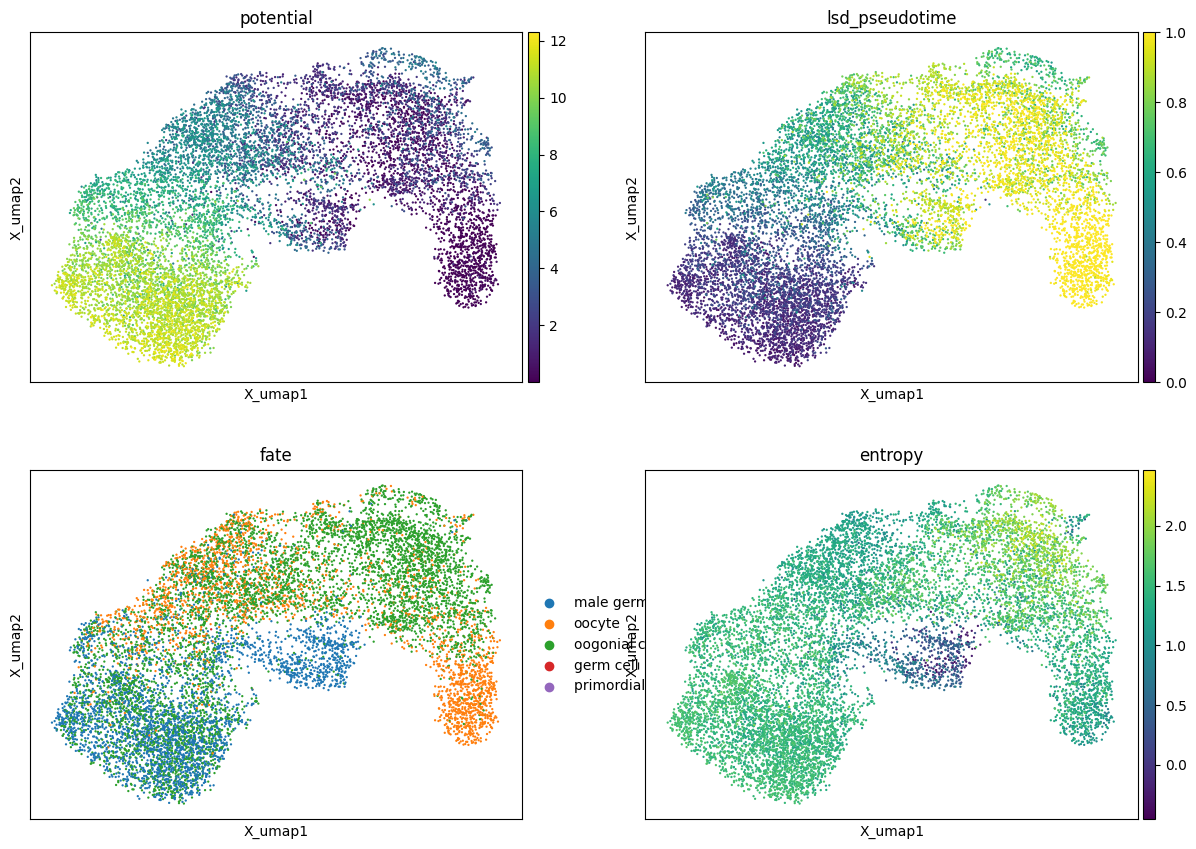

plotting LSD outputs on diffrentiation state projection


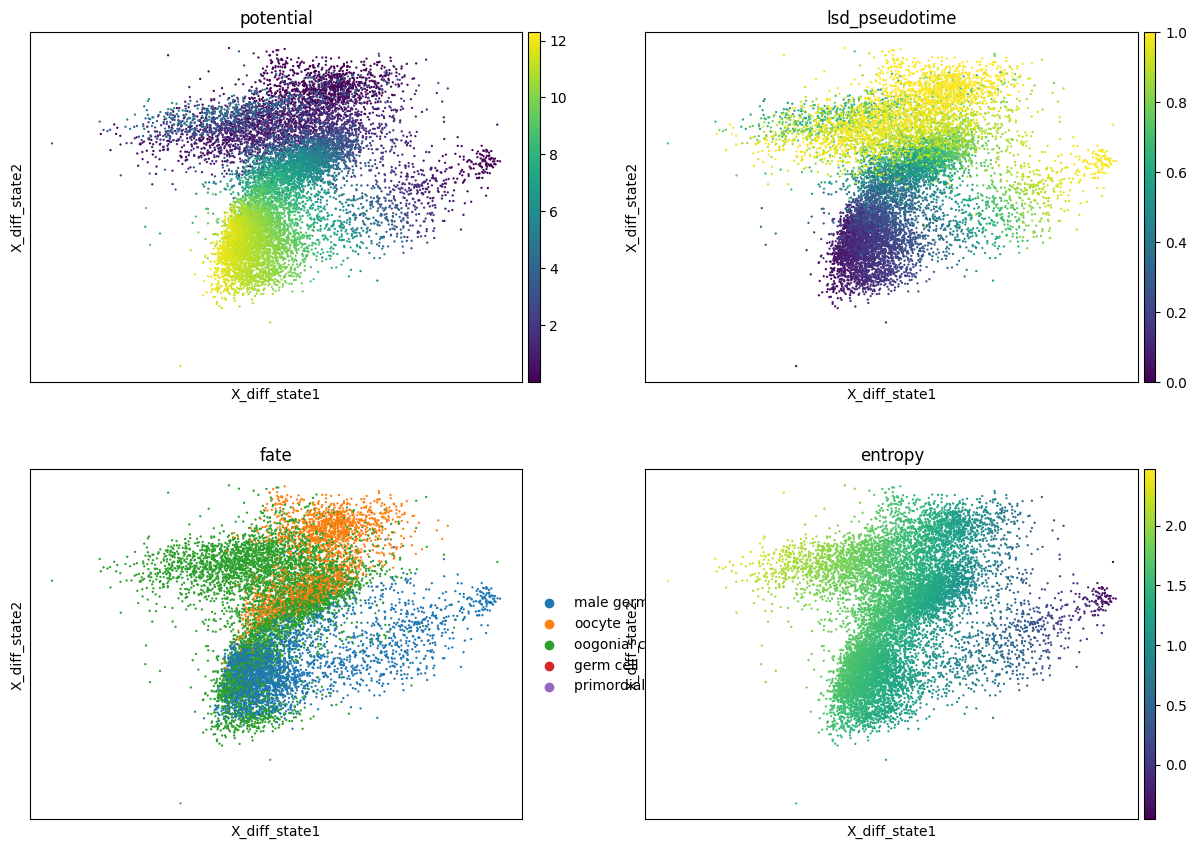

plotting LSD streamlines on UMAP projection


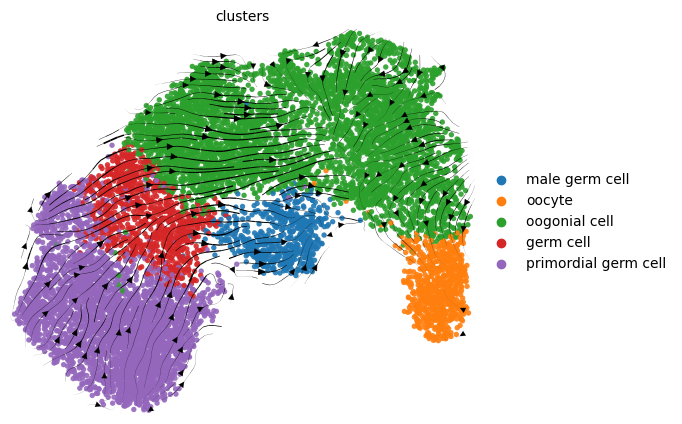

plotting LSD streamlines on diffrentiation state projection


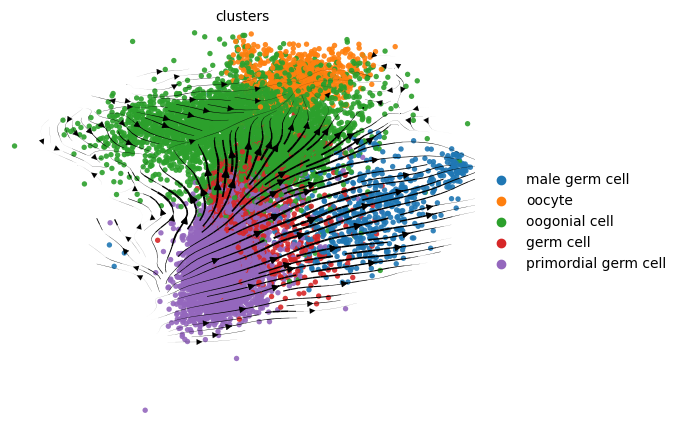

<Axes: title={'center': 'clusters'}>

In [10]:
#plot lsd outputs
dyn_adata.uns["fate_colors"] = dyn_adata.uns["clusters_colors"]
cols = ["potential", "lsd_pseudotime", "fate", "entropy"]

print("="* 60)
print("plotting LSD outputs on UMAP projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_umap", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on UMAP projection")
print("="* 60)
lsd.stream_lines(embedding= "X_umap", size = 60)

print("="* 60)
print("plotting LSD streamlines on diffrentiation state projection")
print("="* 60)
lsd.stream_lines(embedding= "X_diff_state", size = 60)

In [13]:
adata.obs["clusters"]

FCA_GND8047885_AAGACCTCAGTATAAG       primordial germ cell
FCA_GND8047885_AAGGTTCAGTTAAGTG       primordial germ cell
FCA_GND8047885_CCTCTGAAGTGACATA       primordial germ cell
FCA_GND8047885_CGAACATAGCCGGTAA       primordial germ cell
FCA_GND8047885_CGTGAGCTCATCATTC       primordial germ cell
                                              ...         
HCA_F_GON10941968_CTCTACGGTTGATTCG    primordial germ cell
HCA_F_GON10941968_GCACTCTCAGTCACTA    primordial germ cell
HCA_F_GON10941968_TTTATGCAGTAGCGGT    primordial germ cell
HCA_F_GON10941969_AAGTCTGCAAGGTTCT    primordial germ cell
HCA_F_GON10941969_ACCGTAATCTTCGGTC    primordial germ cell
Name: clusters, Length: 10993, dtype: category
Categories (5, object): ['male germ cell', 'oocyte', 'oogonial cell', 'germ cell', 'primordial germ cell']

In [17]:
# calculate CBDir
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection
#define the cluster phylogeny
cluster_edges = [
    ("primordial germ cell", "germ cell"),
    ("germ cell", "male germ cell"),
    ("germ cell", "oogonial cell"),
    ("oogonial cell", "oocyte"),
]
#use cellrank for projecting velocity on tSNE embedding
kernel = ConnectivityKernel(final_adata)
kernel.transition_matrix = final_adata.obsp["transitions"]
proj = TmatProjection(kernel, basis="X_umap")
proj.project(
    key_added="velocity_umap",
    recompute=True,
    connectivities=final_adata.obsp["connectivities"]
)
# cellrank expects neighbor indices stored
indices = final_adata.obsp['distances'].tolil().rows
final_adata.uns['neighbors']['indices'] = indices

#measure CBDir
all_scores, metrics = cross_boundary_correctness(
    final_adata,
    k_cluster="clusters",
    k_velocity="velocity_umap",
    cluster_edges=cluster_edges,
    x_emb="X_umap"
)
# Display results
print("\nCross-boundary correctness scores:")
for edge, score in all_scores.items():
    print(f"  {edge}: {score:.3f}")

# Compute summary statistics
average_all = np.mean(list(all_scores.values()))

print(f"\nOverall average: {average_all:.3f}")


Cross-boundary correctness scores:
  ('primordial germ cell', 'germ cell'): 0.506
  ('germ cell', 'male germ cell'): 0.378
  ('germ cell', 'oogonial cell'): 0.353
  ('oogonial cell', 'oocyte'): 0.488

Overall average: 0.431
